### **1. Install tacoreader**

## **2. Load a TACO compliant dataset**

In [1]:
import autoroot
import tacoreader
from shapely import wkb
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger



from src.pretraining.dataloader import Cloud3DDataModule
from src.pretraining.transforms import GeoSatTransform
from src.pretraining.model import UNetAutoencoder


/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadat

In [2]:
# read taco dataset 
tacoreader.use("pandas")
goes = tacoreader.load("/data/databases/CLOUD_3D/pretraining/tacos/pretraining/goes/")
himawari = tacoreader.load("/data/databases/CLOUD_3D/pretraining/tacos/pretraining/himawari/")
msg = tacoreader.load("/data/databases/CLOUD_3D/pretraining/tacos/pretraining/msg/")

# User columns + navigation columns
user_cols = ['"cloud3d:satellite" AS satellite', '"stac:time_start" AS date','"stac:centroid" AS centroid']
nav_cols = [f'"{c}"' for c in goes.navigation_columns()]
cols = ', '.join(user_cols + nav_cols)

# Filter each dataset
goes_filtered = goes.sql(f"SELECT {cols} FROM data")
himawari_filtered = himawari.sql(f"SELECT {cols} FROM data")
msg_filtered = msg.sql(f"SELECT {cols} FROM data")
# Concat
full_dataset = tacoreader.concat([goes_filtered, himawari_filtered, msg_filtered])
dataset = full_dataset.data.to_pandas()

# add coordinates as geometry 
dataset["geometry"] = dataset.centroid.apply(lambda v: wkb.loads(bytes(v)) if v is not None else None)
dataset = gpd.GeoDataFrame(dataset, geometry="geometry", crs="EPSG:4326")
dataset["lon"] = dataset.geometry.x
dataset["lat"] = dataset.geometry.y


In [3]:
# get table of satellite percentage of samples
dataset['satellite'].value_counts(normalize=True)

satellite
GOES        0.397260
HIMAWARI    0.385475
MSG         0.217265
Name: proportion, dtype: float64

In [4]:
SPLITS_DICT = {
    "train": {
        "years": np.arange(2004, 2025).tolist(),
        "months": np.arange(1, 13).tolist(),
        "days": np.arange(2, 23).tolist(),
    },
    "val": {
        "years": np.arange(2004, 2025).tolist(),
        "months": np.arange(1, 13).tolist(),
        "days": np.arange(24, 27).tolist(),
    },
    "test": {
        "years": np.arange(2004, 2025).tolist(),
        "months": np.arange(1, 13).tolist(),
        "days": np.arange(28, 32).tolist(),
    },
}

def add_split_column(df: pd.DataFrame, date_col: str = "date", split_col: str = "split") -> pd.DataFrame:
    df = df.copy()

    # ensure datetime
    df[date_col] = pd.to_datetime(df[date_col])

    y = df[date_col].dt.year
    m = df[date_col].dt.month
    d = df[date_col].dt.day

    # start with NaN / unknown
    split = pd.Series(pd.NA, index=df.index, dtype="string")

    for name, spec in SPLITS_DICT.items():
        mask = (
            y.isin(spec["years"]) &
            m.isin(spec["months"]) &
            d.isin(spec["days"])
        )
        split.loc[mask] = name

    df[split_col] = split
    return df


In [5]:
dataset = add_split_column(dataset, date_col="date")
dataset.head()

,centroid,date,id,satellite,type,internal:gdal_vsi,geometry,lon,lat,split
0,b'\x01\x01\x00\x00\x00\xe5WM\x87atY\xc00\x0e\x...,2018-06-06 00:00:50,20180606000050_2018157N14255,GOES,FILE,"/vsisubfile/220_3261307,/data/databases/CLOUD_...",POINT (-101.81845 16.9349),-101.818453,16.934899,train
1,b'\x01\x01\x00\x00\x00P\xe12\x07\xd6uY\xc0\xf4...,2018-06-06 00:15:50,20180606001550_2018157N14255,GOES,FILE,"/vsisubfile/3261590_3235675,/data/databases/CL...",POINT (-101.84119 16.93543),-101.841188,16.935426,train
2,b'\x01\x01\x00\x00\x00\xaa\xc7sg\x91wY\xc0L\x1...,2018-06-06 00:30:50,20180606003050_2018157N14255,GOES,FILE,"/vsisubfile/6497328_3196762,/data/databases/CL...",POINT (-101.86825 16.95517),-101.868250,16.955168,train
3,b'\x01\x01\x00\x00\x00\xc0\xb8(Y\xfaxY\xc0\xce...,2018-06-06 00:45:50,20180606004550_2018157N14255,GOES,FILE,"/vsisubfile/9694153_3078801,/data/databases/CL...",POINT (-101.89028 16.95568),-101.890280,16.955679,train
4,b'\x01\x01\x00\x00\x00F tgczY\xc0\xdf.e\xee\xc...,2018-06-06 01:00:50,20180606010050_2018157N14255,GOES,FILE,"/vsisubfile/12773017_2777913,/data/databases/C...",POINT (-101.91232 16.95619),-101.912317,16.956191,train


In [20]:
from lightning.pytorch import seed_everything
seed_everything(43, workers=True)

transform = GeoSatTransform(patch_size=[128, 128], center_crop=True, radius=32)
dm = Cloud3DDataModule(dataset, transform)

Seed set to 43
2026-02-04 12:48:39.112 | INFO     | src.pretraining.dataloader:__init__:35 - There are 230134 files in taco dataset
2026-02-04 12:48:40.292 | INFO     | src.pretraining.dataloader:__init__:60 - MSG DataModule initialized ...
2026-02-04 12:48:40.294 | INFO     | src.pretraining.dataloader:__init__:61 - Length of train dataset: 155937
2026-02-04 12:48:40.295 | INFO     | src.pretraining.dataloader:__init__:62 - Length of test dataset: 27633
2026-02-04 12:48:40.296 | INFO     | src.pretraining.dataloader:__init__:63 - Length of val dataset: 22168


In [21]:
it = iter(dm.train_sampler)
print([next(it) for _ in range(20)])

[115307, 67414, 33834, 127916, 153960, 93829, 27983, 54993, 76870, 126781, 141295, 108172, 9976, 91419, 145284, 121727, 76522, 66923, 954, 148138]


In [ ]:
model = UNetAutoencoder(
    in_channels=17,
    recon_channels=11,
    encoder_name="resnet34",
    encoder_weights=None,
    lr=1e-3,
)

In [9]:
dir_save = "/data/users/emiliano/3DcloudsData/output/notebooks/"
file_nm = "ae-{epoch:03d}-{val_loss:.4f}"
dir_save+file_nm

'/data/users/emiliano/3DcloudsData/output/notebooks/ae-{epoch:03d}-{val_loss:.4f}'

In [10]:
checkpoint_cb = ModelCheckpoint(
    monitor="val_loss",      # or "train/loss"
    mode="min",
    save_top_k=3,
    save_last=True,         # saves last.ckpt
    filename=file_nm,
)

logger = CSVLogger(save_dir=dir_save, name="cloud_ae")

trainer = pl.Trainer(accelerator="gpu", devices=1, max_epochs=3, 
                     limit_train_batches=0.001,
                     limit_val_batches=0.005,
                    limit_test_batches=0.005,
                        callbacks=[checkpoint_cb],
                        logger=logger)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [11]:
trainer.fit(model, datamodule=dm)

You are using a CUDA device ('NVIDIA RTX A5500') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ net  │ Unet │ 24.5 M │ train │     0 │
└───┴──────┴──────┴────────┴───────┴───────┘

Trainable params: 24.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.5 M                                                                                               
Total estimated model params size (MB): 97                                                                         
Modules in train mode: 188                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/lightning/pytorch/trainer/co
nnectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider
increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.

...

/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/lightning/pytorch/trainer/co
nnectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve 
performance.

/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/lightning/pytorch/loops/fit_
loop.py:317: The number of training batches (38) is smaller than the logging interval 
Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training 
epoch.


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [21]:
version = '8'
df = pd.read_csv(dir_save+"cloud_ae/version_"+version+"/metrics.csv")
print(df.head())

   epoch  step  train_loss_epoch  train_loss_step   val_loss
0      0    37               NaN              NaN  20.332170
1      0    37          0.050028              NaN        NaN
2      1    49               NaN         0.101017        NaN
3      1    75               NaN              NaN   0.066623
4      1    75          0.039795              NaN        NaN


In [22]:
# remove rows with NaN val/loss
df.dropna(subset=['val_loss'])

,epoch,step,train_loss_epoch,train_loss_step,val_loss
0,0,37,NaN,NaN,20.332170
3,1,75,NaN,NaN,0.066623
6,2,113,NaN,NaN,0.025392


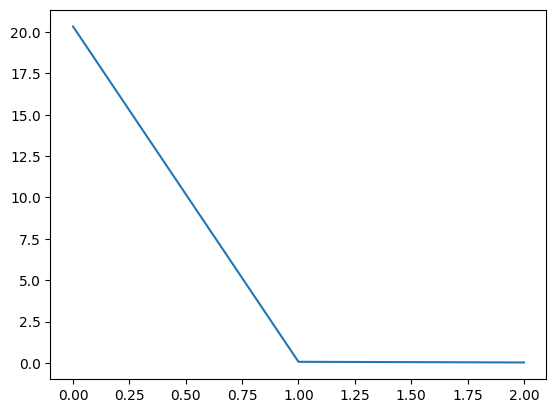

In [23]:
# get validation curves from csv
import matplotlib.pyplot as plt
plt.plot(df.dropna(subset=['val_loss'])["epoch"], df.dropna(subset=['val_loss'])["val_loss"], label="val_loss")




In [24]:
# train model for another 3 epochs
trainer = pl.Trainer(accelerator="gpu", devices=1, max_epochs=3+3, 
                     limit_train_batches=0.001,
                     limit_val_batches=0.005,
                    limit_test_batches=0.005,
                        callbacks=[checkpoint_cb],
                        logger=logger)
trainer.fit(model, datamodule=dm, ckpt_path=checkpoint_cb.best_model_path)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /data/users/emiliano/3DcloudsData/output/notebooks/cloud_ae/version_8/checkpoints exists and is not empty.
Restoring states from the checkpoint path at /data/users/emiliano/3DcloudsData/output/notebooks/cloud_ae/version_8/checkpoints/ae-epoch=002-val_loss=0.0254.ckpt


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ net  │ Unet │ 24.5 M │ train │     0 │
└───┴──────┴──────┴────────┴───────┴───────┘

Trainable params: 24.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.5 M                                                                                               
Total estimated model params size (MB): 97                                                                         
Modules in train mode: 188                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Restored all states from the checkpoint at /data/users/emiliano/3DcloudsData/output/notebooks/cloud_ae/version_8/checkpoints/ae-epoch=002-val_loss=0.0254.ckpt


Output()

/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/lightning/pytorch/trainer/co
nnectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider
increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.

/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/lightning/pytorch/trainer/co
nnectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve 
performance.

/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/lightning/pytorch/loops/fit_
loop.py:317: The number of training batches (38) is smaller than the logging interval 
Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training 
epoch.

`Trainer.fit` stopped: `max_epochs=6` reached.


In [25]:
df = pd.read_csv(dir_save+"cloud_ae/version_"+version+"/metrics.csv")
df.dropna(subset=['val_loss'])

,epoch,step,train_loss_epoch,train_loss_step,val_loss
0,0,37,NaN,NaN,20.332170
3,1,75,NaN,NaN,0.066623
6,2,113,NaN,NaN,0.025392
9,3,151,NaN,NaN,0.020944
11,4,189,NaN,NaN,0.096121
14,5,227,NaN,NaN,0.130958


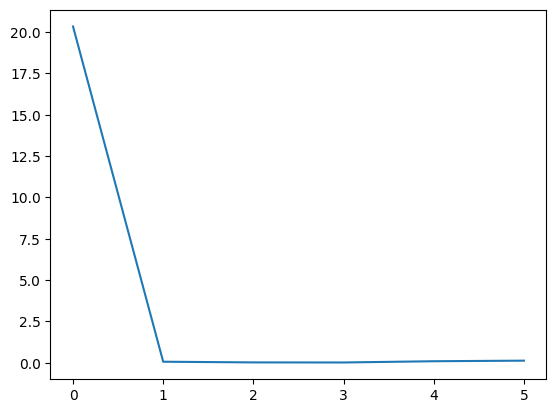

In [26]:
plt.plot(df.dropna(subset=['val_loss'])["epoch"], df.dropna(subset=['val_loss'])["val_loss"], label="val_loss")


In [27]:
df

,epoch,step,train_loss_epoch,train_loss_step,val_loss
0,0,37,NaN,NaN,20.332170
1,0,37,0.050028,NaN,NaN
2,1,49,NaN,0.101017,NaN
3,1,75,NaN,NaN,0.066623
4,1,75,0.039795,NaN,NaN
5,2,99,NaN,0.021181,NaN
6,2,113,NaN,NaN,0.025392
7,2,113,0.043553,NaN,NaN
8,3,149,NaN,0.021930,NaN
9,3,151,NaN,NaN,0.020944


In [28]:
#look at metrics
trainer.test(model, datamodule=dm)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.11344359070062637    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.11344359070062637}]